# Tutorial 1: Basic Static Simulation

Welcome to the **nanonets** introductory tutorial! 

In this notebook, we will cover the absolute basics of setting up a nanoparticle network and running a time-independent (static voltage) Kinetic Monte Carlo (KMC) simulation. This is the foundation for modeling single-electron transport.

First, let's import the required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nanonets

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 1. Defining the Network Topology

Before we can simulate electron transport, we need to define the physical layout of our nanoparticle network. `nanonets` uses a simple dictionary to configure this. 

For this basic example, we will build a small 3x3 square lattice:
* **`Nx`, `Ny`**: The dimensions of our grid (3 particles wide, 3 particles high).
* **`e_pos`**: The grid coordinates for our electrodes. We place one at the bottom-left `[0, 0]` and one at the top-right `[2, 2]`.
* **`electrode_type`**: We set both to `'constant'`, meaning they will act as ideal voltage sources (source and drain) rather than floating gates.

Finally, we initialize the main `Simulation` object. We set the self-capacitance (`self_cap` or $C_S$) of the particles to zero for this ideal, purely junction-coupled case.

In [2]:
lattice_topology = {
    "Nx" : 3,
    "Ny" : 3,
    'e_pos': [[0, 0], [2, 2]],
    'electrode_type': ['constant', 'constant']
}

c_s = 0.0
sim = nanonets.Simulation(topology_parameter=lattice_topology, self_cap=c_s)

## 2. Setting Up the Simulation Parameters

To observe quantum mechanical single-electron effects like the **Coulomb blockade** (a suppression of current at low voltages), we set the temperature to a very low value (`temp = 0.01` K). We then create a voltage sweep from `-0.3 V` to `0.3 V` in `101` steps.

Since KMC is a stochastic method, we must balance computational time with statistical accuracy. We control this using a parameter dictionary:
* **`n_trajectories`**: The number of independent systems simulated in parallel for the ensemble average.
* **`max_eq_jumps`**: The number of electron tunneling events used to let the system reach a steady state (equilibration) before we start measuring.
* **`max_jumps`**: The number of jumps during the actual measurement phase (production).

*Note on performance:* For this small 3x3 tutorial, we use very low values to ensure the simulation finishes in a few seconds. In a real research scenario, you would increase these values significantly (e.g., `n_trajectories=400`, `max_eq_jumps=100000`) for smoother curves and smaller error bars.

*Note on saving data:* If you run large simulations that take hours, you can add `"save_th": 10` to the dictionary. This tells the simulator to save the intermediate data to your hard drive after every 10th voltage step, preventing data loss in case of an interruption.

*Note on Parallelization:* In this tutorial, we computed the voltage points sequentially. However, static KMC points are entirely independent, making this an *embarrassingly parallel* problem.

In [3]:
temp = 0.01
n_volts = 101
v_range = 0.3

# Initialize voltage array: (N_samples, N_electrodes + 1)
voltages = np.zeros(shape=(n_volts, len(lattice_topology["e_pos"]) + 1))

# Sweep the first electrode (Source)
voltages[:, 0] = np.linspace(-v_range, v_range, n_volts)

# Define simulation parameters for a fast tutorial run
sim_dic = {
    "n_trajectories" : 50,
    "max_eq_jumps"   : 5000,
    "max_jumps"      : 2000,
}

# Run the KMC simulation
sim.run_static_voltages(voltages=voltages, target_electrode=1, T_val=temp, sim_dic=sim_dic)

## 3. Visualizing the Results: The Coulomb Blockade

Now that the simulation is finished, we can extract and plot the results. 
Since KMC is a stochastic algorithm, the measured current at each voltage step is an ensemble average and comes with a statistical error. We will plot the current ($I$) against the applied voltage ($U$) including these error bars.

Notice how the units are scaled for readability: voltages are converted to millivolts (mV) and the current is scaled to picoamperes (pA).

When you look at the plot, you should clearly see the **Coulomb gap**—a flat region around $0 \text{ V}$ where the current is completely suppressed. The electrons simply do not have enough energy to overcome the charging energy of the network!

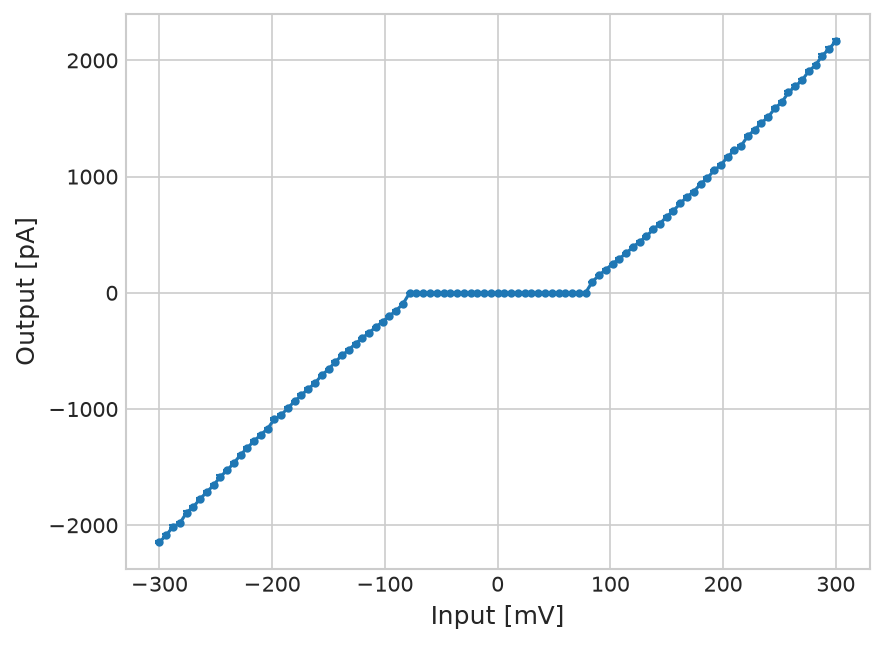

In [4]:
# Extract data and scale to mV and pA
x = voltages[:, 0].copy() * 1000
y = sim.get_observable_storage() * 1e-6
y_e = sim.get_observable_error_storage() * 1e-6

# Plot the I-V curve with error bars
fig, ax = plt.subplots(dpi=150)
_ = ax.errorbar(x, y, yerr=y_e, fmt='.-', capsize=2)
_ = ax.set_xlabel("Input [mV]", size='large')
_ = ax.set_ylabel("Output [pA]", size='large')

## 4. Internal Network States: Potentials and Currents

So far, we have only looked at the macroscopic observable: the total current flowing into the target electrode. However, `nanonets` also tracks the internal state of the nanoparticle network.

By default, the simulation stores the electrostatic potential of every single electrode and nanoparticle at each time step. The method `sim.get_potential_storage()` returns a 2D array of shape `(N_samples, N_electrodes + N_particles)`. To visualize the landscape of the nanoparticles, we can simply slice off the first few columns that belong to the electrodes.

**What about internal currents and charge distributions?**
For very large networks, tracking every single tunneling event between every nanoparticle requires a lot of memory. Therefore, these features are disabled by default. If you need to analyze the network's internal current paths or dynamic resistances, you can pass `verbose=True` to the `run_` methods.

For now, let's use a built-in visualization utility to plot the electrostatic potential landscape of our 3x3 nanoparticle grid at the maximum applied voltage.

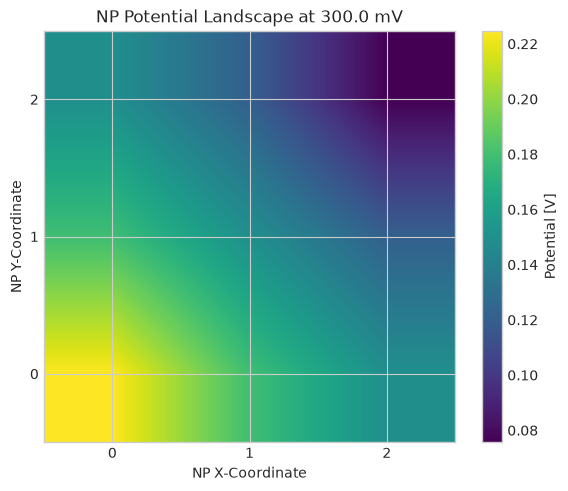

In [5]:
from nanonets.utils.plotting import display_landscape

# 1. Get the potential array: Shape is (N_samples, N_electrodes + N_particles)
all_potentials = sim.get_potential_storage()

# 2. Extract only the nanoparticles by skipping the electrode columns
n_electrodes = len(lattice_topology["e_pos"])
np_potentials = all_potentials[:, n_electrodes:]

# 3. Select the data at the maximum voltage (the very last step in our sweep)
max_voltage_step = -1
landscape_data = np_potentials[max_voltage_step, :]

# 4. Plot the 3x3 landscape
fig, ax = display_landscape(
    data_row=landscape_data, 
    Nx=lattice_topology["Nx"], 
    Ny=lattice_topology["Ny"], 
    cmap='viridis', 
    colorbar=True, 
    cbar_label='Potential [V]',
    x_label='NP X-Coordinate',
    y_label='NP Y-Coordinate',
    interpolation='bilinear',
)

# Optional: Add a title indicating the applied voltage
applied_v = voltages[max_voltage_step, 0] * 1000
ax.set_title(f"NP Potential Landscape at {applied_v:.1f} mV")

plt.show()

## 5. Animating the Potential Landscape

Since we performed a voltage sweep over 51 steps, we don't just have a single snapshot of the network—we have a complete time-series of the potential building up across the nanoparticles. 

We can use the `animate_landscape` utility to create a video of this process. To display Matplotlib animations interactively within a Jupyter Notebook, we need to convert the animation object to HTML using `IPython.display.HTML`.

In [6]:
from IPython.display import HTML
from nanonets.utils.plotting import animate_landscape
import matplotlib.pyplot as plt

# Create the animation object using our full array of nanoparticle potentials
ani = animate_landscape(
    landscape=np_potentials, 
    Nx=lattice_topology["Nx"], 
    Ny=lattice_topology["Ny"], 
    cmap='coolwarm', 
    cbar_label='Potential [V]',
    plot_steps=True,
    delay_between_frames=100,  # A bit faster for a smooth 51-frame sweep
    interpolation='bilinear',
)

# Prevent Matplotlib from showing a static, duplicate image below the video
plt.close()

# Render the animation as an interactive HTML widget
HTML(ani.to_jshtml())

## 6. Advanced Visualization: Network Currents

When simulating larger networks or looking for *percolation paths* (the main routes electrons take through the grid), it is highly useful to visualize the internal currents. 

Because tracking every single jump in a large network consumes extra memory and time, this feature requires running the simulation with `verbose=True`. Let's quickly re-run our fastest voltage step with verbosity enabled to capture the internal network currents. 

Using the `nanonets.utils.plotting` module, we can then map these currents onto a `networkx` graph. The thickness and color of the arrows indicate the net current direction and magnitude (logarithmically scaled).

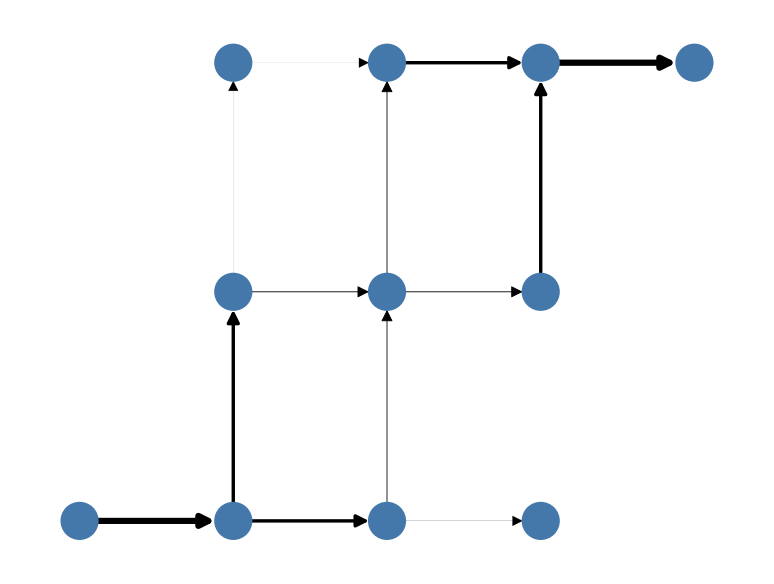

In [7]:
from nanonets.utils.plotting import display_network_currents

# 1. Run a single high-voltage step with verbose=True
verbose_sim_dic = {
    "n_trajectories" : 50,
    "max_eq_jumps"   : 5000,
    "max_jumps"      : 2000
}

# We use only the highest voltage from our previous array
single_voltage = voltages[-1:] 

sim.run_static_voltages(
    voltages=single_voltage, 
    target_electrode=1, 
    T_val=temp, 
    sim_dic=verbose_sim_dic, 
    verbose=True
)

# 2. Extract required topology and state data
internal_current_dict = sim.get_network_current_storage()
n_electrodes = len(lattice_topology["e_pos"])
pos_dict = sim.topology.get_positions()
all_potentials = sim.get_potential_storage()

# 3. Plot the current network
fig, ax = plt.subplots(dpi=150)
fig, ax = display_network_currents(
    current_dict=internal_current_dict, 
    N_electrodes=n_electrodes,
    pos=pos_dict, 
    fig=fig, 
    ax=ax
)

## 7. Visualizing the Physical Device Topology

While the previous directed graph shows the exact routing of internal currents, it abstracts away the physical dimensions of our network. To get a more realistic view of the device, we can plot the physical topology using the actual coordinates and radii of the nanoparticles.

We will use the `display_network` utility to draw the physical layout. Afterwards, we use `update_circle_colors` to overlay the electrostatic potential at our highest applied voltage onto the drawn particles. 

*Note on data structures:* The `all_potentials` array stores the electrode potentials first, followed by the nanoparticle potentials. Since our drawing function renders the nanoparticles first, we simply concatenate the arrays in the matching order before updating the colors.

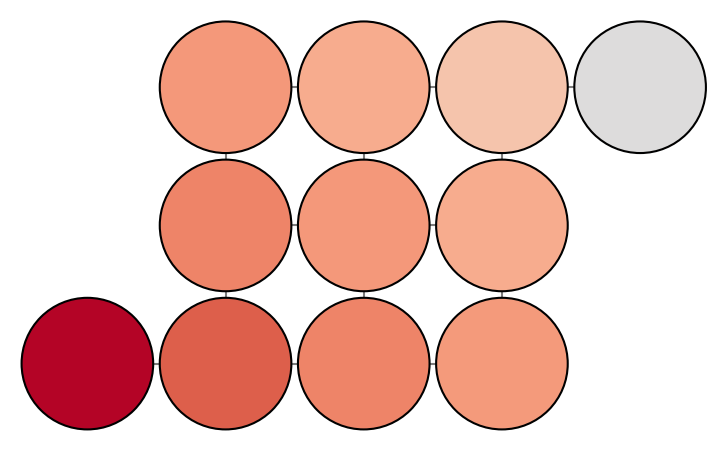

In [8]:
from nanonets.utils.plotting import display_network, update_circle_colors

# 1. Fetch topology properties from the simulation object
G = sim.topology.get_graph()
pos_dict = sim.topology.get_positions()
radii = sim.topology.get_radius()

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

# 2. Draw the physical network layout (edges and circles)
display_network(
    G=G, 
    pos=pos_dict, 
    radius=radii, 
    fig=fig, 
    ax=ax
)

# 3. Color the circles based on their potential and add a colorbar
update_circle_colors(
    ax=ax, 
    pot=all_potentials[-1,:],
    colorbar=False
)